In [77]:
import pandas as pd
import numpy as np
print("Pandas working:", pd.__version__)
pd.options.display.float_format = '{:.0f}'.format


Pandas working: 3.0.2


In [78]:

import os

print(os.path.exists("../data/Retail_Sales_Data_Unlox (1).csv"))
os.getcwd()
os.listdir("../data")

True


['cleaned_data.csv',
 'forecast.csv',
 'Retail_Sales_Data_Unlox (1).csv',
 'store_clusters.csv']

In [79]:
df = pd.read_csv("../data/Retail_Sales_Data_Unlox (1).csv")
df.head()

,Date,Store_ID,Store_Location,Product_ID,Product_Category,Product_Subcategory,Brand,Unit_Price,Units_Sold,Total_Sales,Discount_Percentage,Revenue,Customer_Type,Payment_Mode,Promotion_Applied,Stock_On_Hand,Store_Rating,Region,Holiday_Flag
0,2023-04-13,STR_104,Chennai,PRD_072,Sports,Athletics,Reebok,29973,39,1168949,5,1110502,Returning,Debit Card,Yes,422,4,South,0
1,2024-10-25,STR_103,Delhi,PRD_492,Sports,Outdoor,Yonex,46934,2,93868,15,79787,Returning,UPI,No,302,4,North,0
2,2023-02-28,STR_107,Kolkata,PRD_958,Groceries,Household,Nestle,39280,44,1728332,15,1469082,Returning,Cash,No,184,4,East,0
3,2023-06-16,STR_102,Bangalore,PRD_014,Home Appliances,Kitchen,Whirlpool,40439,9,363951,5,345754,New,UPI,Yes,493,4,South,0
4,2024-05-23,STR_108,Ahmedabad,PRD_932,Fashion,Women Clothing,Puma,9194,4,36774,5,34936,Returning,Credit Card,No,359,4,West,0


In [80]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 73000 entries, 0 to 72999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 73000 non-null  str    
 1   Store_ID             73000 non-null  str    
 2   Store_Location       73000 non-null  str    
 3   Product_ID           73000 non-null  str    
 4   Product_Category     73000 non-null  str    
 5   Product_Subcategory  73000 non-null  str    
 6   Brand                73000 non-null  str    
 7   Unit_Price           73000 non-null  float64
 8   Units_Sold           73000 non-null  int64  
 9   Total_Sales          73000 non-null  float64
 10  Discount_Percentage  73000 non-null  int64  
 11  Revenue              73000 non-null  float64
 12  Customer_Type        73000 non-null  str    
 13  Payment_Mode         73000 non-null  str    
 14  Promotion_Applied    73000 non-null  str    
 15  Stock_On_Hand        73000 non-null  int64  
 1

,Unit_Price,Units_Sold,Total_Sales,Discount_Percentage,Revenue,Stock_On_Hand,Store_Rating,Holiday_Flag
count,73000,73000,73000,73000,73000,73000,73000,73000
mean,25110,25,626138,10,563476,275,4,0
std,14394,14,544855,7,493891,130,0,0
min,100,1,145,0,123,50,4,0
25%,12729,13,175985,5,157538,162,4,0
50%,25072,25,471358,10,422356,274,4,0
75%,37557,37,953986,15,857116,387,5,0
max,50000,49,2447350,20,2447350,499,5,1


In [81]:
df['Date'] = pd.to_datetime(df['Date'])

In [82]:
df.isnull().sum()

Date                   0
Store_ID               0
Store_Location         0
Product_ID             0
Product_Category       0
Product_Subcategory    0
Brand                  0
Unit_Price             0
Units_Sold             0
Total_Sales            0
Discount_Percentage    0
Revenue                0
Customer_Type          0
Payment_Mode           0
Promotion_Applied      0
Stock_On_Hand          0
Store_Rating           0
Region                 0
Holiday_Flag           0
dtype: int64

In [83]:
df = df.dropna()

In [84]:
df = df.drop_duplicates()

In [85]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.day_name()

In [86]:
df.columns

Index(['Date', 'Store_ID', 'Store_Location', 'Product_ID', 'Product_Category',
       'Product_Subcategory', 'Brand', 'Unit_Price', 'Units_Sold',
       'Total_Sales', 'Discount_Percentage', 'Revenue', 'Customer_Type',
       'Payment_Mode', 'Promotion_Applied', 'Stock_On_Hand', 'Store_Rating',
       'Region', 'Holiday_Flag', 'Year', 'Month', 'Day', 'Weekday'],
      dtype='str')

In [87]:
sales_trend = df.groupby('Date')['Revenue'].sum()
sales_trend.head()

Date
2023-01-01   51980722
2023-01-02   50112156
2023-01-03   54389813
2023-01-04   53089145
2023-01-05   59540547
Name: Revenue, dtype: float64

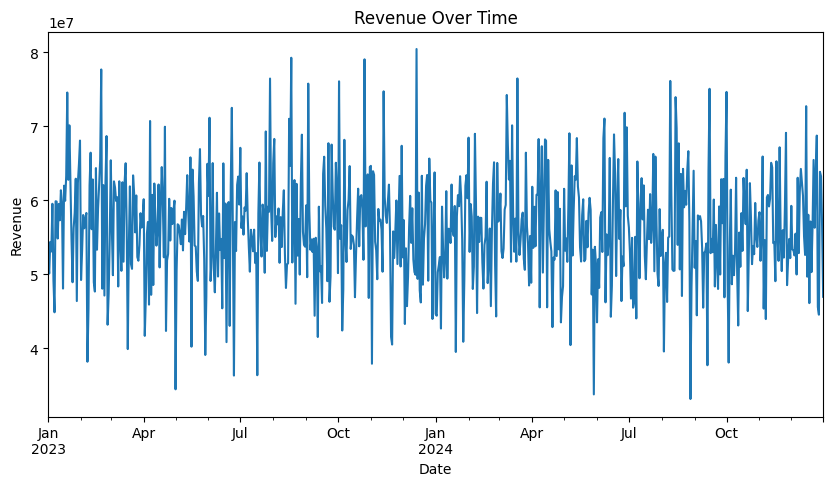

In [88]:
import matplotlib.pyplot as plt

sales_trend.plot(figsize=(10,5))
plt.title("Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

In [89]:
store_sales = df.groupby('Store_ID')['Revenue'].sum().sort_values(ascending=False)
store_sales.head(10)

Store_ID
STR_103   5223064264
STR_102   5186276606
STR_101   5169675267
STR_104   5165937478
STR_105   5161898682
STR_107   5107832302
STR_108   5078321969
STR_106   5040776297
Name: Revenue, dtype: float64

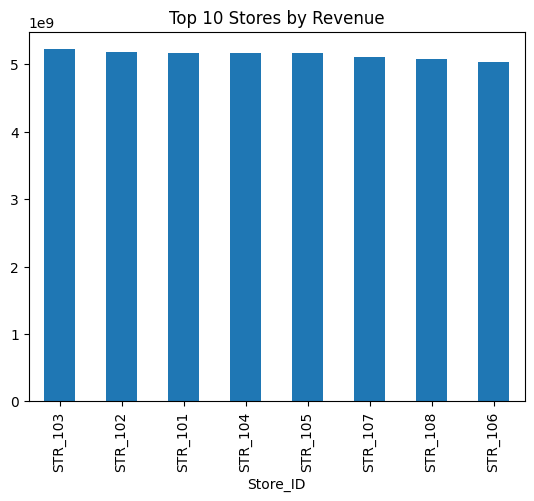

In [90]:
store_sales.head(10).plot(kind='bar')
plt.title("Top 10 Stores by Revenue")
plt.show()

In [91]:
monthly_sales = df.groupby('Month')['Revenue'].sum()
monthly_sales

Month
1    3482487885
2    3189201241
3    3554003332
4    3364584836
5    3448136777
6    3383239192
7    3477514782
8    3561132585
9    3332492941
10   3480589061
11   3383348673
12   3477051559
Name: Revenue, dtype: float64

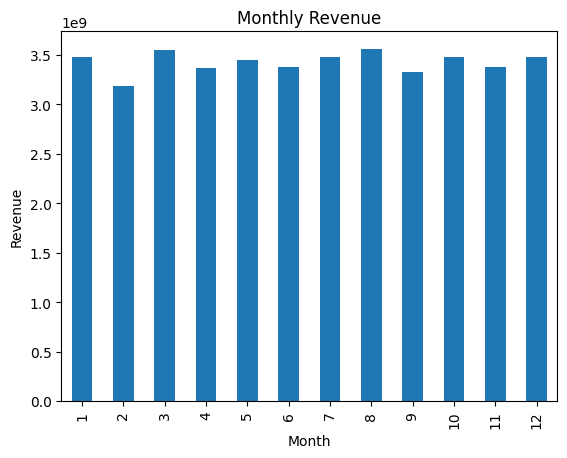

In [92]:
monthly_sales.plot(kind='bar')
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [93]:
category_sales = df.groupby('Product_Category')['Revenue'].sum().sort_values(ascending=False)
category_sales

Product_Category
Electronics       8318538869
Home Appliances   8262751184
Fashion           8215645303
Groceries         8170528430
Sports            8166319079
Name: Revenue, dtype: float64

In [94]:
import pandas as pd
pd.options.display.float_format = '{:.0f}'.format

In [95]:
region_sales = df.groupby('Region')['Revenue'].sum()
region_sales
region_sales.apply(lambda x: f"{x:,.0f}")

Region
East      5,107,832,302
North     5,223,064,264
South    15,392,990,381
West     15,409,895,918
Name: Revenue, dtype: str

In [96]:
df['Is_Weekend'] = df['Weekday'].isin(['Saturday', 'Sunday']).astype(int)
df['Discount_Amount'] = df['Total_Sales'] * (df['Discount_Percentage'] / 100)

In [97]:
store_data = df.groupby('Store_ID').agg({
    'Revenue': 'sum',
    'Units_Sold': 'sum',
    'Store_Rating': 'mean'
}).reset_index()

store_data.head()

,Store_ID,Revenue,Units_Sold,Store_Rating
0,STR_101,5169675267,226670,4
1,STR_102,5186276606,228384,4
2,STR_103,5223064264,229475,4
3,STR_104,5165937478,228580,4
4,STR_105,5161898682,227715,4


In [98]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
store_data['Cluster'] = kmeans.fit_predict(
    store_data[['Revenue', 'Units_Sold', 'Store_Rating']]
)

store_data.head()

,Store_ID,Revenue,Units_Sold,Store_Rating,Cluster
0,STR_101,5169675267,226670,4,2
1,STR_102,5186276606,228384,4,2
2,STR_103,5223064264,229475,4,0
3,STR_104,5165937478,228580,4,2
4,STR_105,5161898682,227715,4,2


In [99]:
import os

os.makedirs("data", exist_ok=True)
store_data.to_csv("data/store_clusters.csv", index=False)

In [100]:
store_data.to_csv("store_clusters.csv", index=False)

In [101]:
# Weekend vs Weekday sales
weekend_sales = df.groupby('Is_Weekend')['Revenue'].sum()
print(weekend_sales)

holiday_sales = df.groupby('Holiday_Flag')['Revenue'].sum()
print(holiday_sales)

Is_Weekend
0   29343346123
1   11790436742
Name: Revenue, dtype: float64
Holiday_Flag
0   40640914750
1     492868115
Name: Revenue, dtype: float64


23:32:34 - cmdstanpy - INFO - Chain [1] start processing
23:32:41 - cmdstanpy - INFO - Chain [1] done processing


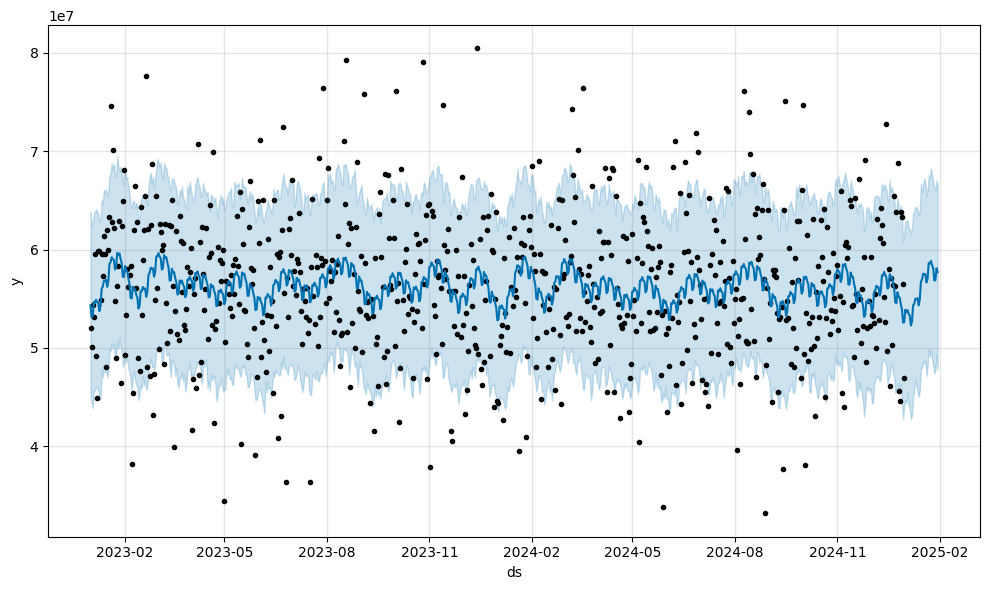

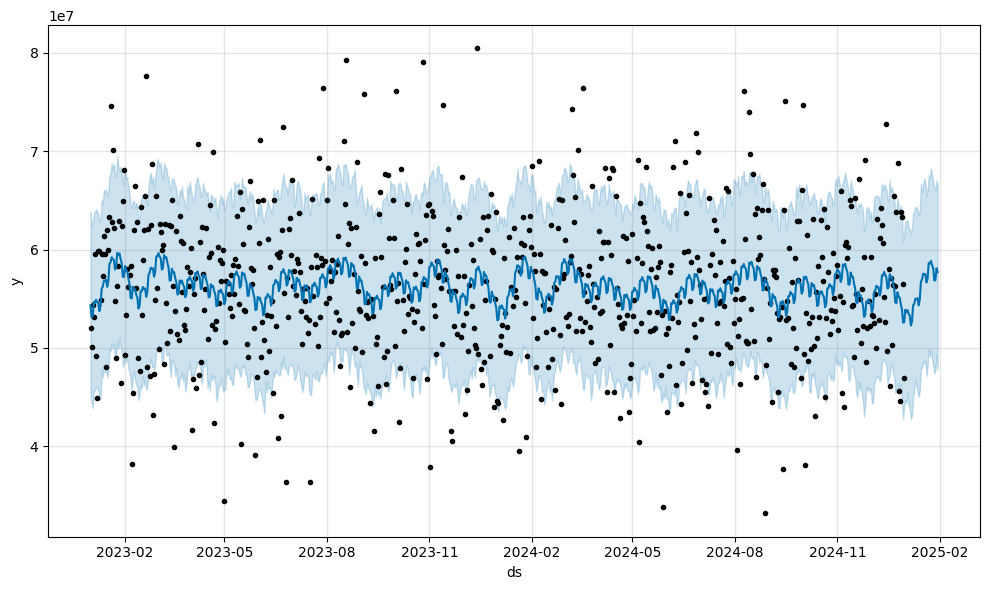

In [102]:
from prophet import Prophet

ts_data = df.groupby('Date')['Revenue'].sum().reset_index()
ts_data.columns = ['ds', 'y']

model = Prophet()
model.fit(ts_data)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

model.plot(forecast)

In [103]:
forecast[['ds','yhat']].to_csv("data/forecast.csv", index=False)

In [104]:
import os

# ensure data folder exists
os.makedirs("data", exist_ok=True)

# save cleaned dataset
df.to_csv("data/cleaned_data.csv", index=False)